# Surfing Waves with Sentinel-2: Cross-Spectra & Wavelets on HEALPix Patches

This notebook is a hands-on demo showing how to build **wave spectra** from Sentinel-2 imagery over the ocean using **two 10 m bands** - **B02 (blue)** and **B04 (red)** - that are acquired with a small time offset. That slight offset means the sea surface evolves just enough between the two snapshots to unlock **cross-spectral** estimation: we can both **reduce spectral bias** and **recover wave phase and directions** from the **cross-spectrum**. 

This demo is inspired by the [EOPF sample notebook on oceanographic wave spectral analysis](https://eopf-sample-service.github.io/eopf-sample-notebooks/oceanographic-wave-spectral-analysis/). 

To understand the scientific background for the wave analysis methods used here, refer to:
[Kudryavtsev et al., 2016](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016JC012425).

Instead of classic FFTs on planar tiles, we resample to a **HEALPix** grid so that all patches share the **same surface per pixel**, then estimate spectra with **wavelets**, which are more robust to noise under the assumption that wave spectra are relatively smooth.

---

## Why B02 x B04 Cross-Spectrum?

- Natural temporal offset: B02 and B04 are acquired a few moments apart. Waves evolve slightly - enough to introduce measurable phase differences while maintaining coherence.
- Cross-spectral benefits:
  - Bias reduction in spectral estimates (compared to single-band autospectra).
  - Phase retrieval -> directions: the cross-spectrum’s complex phase gives propagation directions of waves.
- 10 m resolution: fine enough to resolve short waves; the short offset keeps coherence high at these scales.
- This method is inspired by this publication (REF)

---

## Processing Overview

1. **Input**: Sentinel-2 Level-2A/Level-1C oceanic granules containing **B02** and **B04** at **10 m**.  
2. **Patch building (UTM)**: Cut the UTM imagery into fixed **128x128 pixel** patches (~ 1.28 km on a side).  
3. **UTM -> HEALPix**: Resample each patch onto a **HEALPix** grid so that each pixel covers the **same area** regardless of latitude.  
   *Why?* Fair comparisons of spectral energy require consistent pixel areas. It also solve the problem of north-south orientation definition which not properly defined within one UTM tile in particular at the limit of the tile (see bellow how the orientation of UTM pixel is not following the north-south orientation). 
4. **Wavelet-based spectra**: On the HEALPix patch, compute **wavelet transforms** of B02 and B04 and form the **cross-spectrum**:  
   - Smoother, less noise-sensitive than FFTs in this setting.  
   - Provides **amplitude** (power) and **phase** (direction).  
5. **Direction estimation**: Use the **phase** of the cross-spectrum to infer **wave directions** (and optionally phase speed proxies where applicable).  
6. **Scaling up with xbatcher**: Demonstrate how **xbatcher** can tile large scenes and compute many spectra efficiently across lots of Sentinel-2 data.

---

## What You Will Learn

- How to construct UTM **patches** and resample them to **HEALPix** while preserving radiometry.  
- How to compute **wavelet cross-spectra** between B02 and B04 to:  
  - Reduce estimation bias,  
  - Retrieve **directional** information from **phase**.  
- How to use **xbatcher** to scale the workflow (thousands of patches, large scenes).

---

## Notebook Structure

### 1) From UTM Tiles to HEALPix Patches
- **Load** Sentinel-2 B02 & B04 (10 m).  
- **Window** into **128x128** UTM patches over ocean.  
- **Resample** each patch to **HEALPix** (choose `nside` to match resolution/area).  
- **Validate** area equivalence and basic QC checks (land mask, clouds if needed).

### 2) Wavelet Cross-Spectrum on HEALPix
- **Wavelet transform** (per orientation/scale) on both bands.  
- Build **cross-spectrum** as B02 x conj(B04) across **scales** and **orientations**.  
- **Amplitude** -> spectral energy; **phase** -> **wave direction**.  
- **Visualize**:  
  - 2D spectral maps (k-space-like),  
  - Directional roses,  
  - Scale–orientation slices.

### 3) Scaling with xbatcher
- Use **xbatcher** to generate patch windows automatically.  
- Compute **spectra lazily** (e.g., with Dask) and track progress.  
- Aggregate summary products (mean spectra, dominant direction maps, QC flags).

---

## Why Wavelets (Instead of FFTs)?

- Locality in both scale and space helps suppress noise and edge effects.  
- Ocean wave spectra are smooth; wavelets exploit this by emphasizing coherent structures.  
- Better behaved for irregular sampling after **UTM -> HEALPix** resampling.

---

## Practical Notes

- **Band pairing**: Ensure **B02/B04** are radiometrically harmonized (e.g., same masks, scaled units).  
- **Time offset**: The small acquisition lag is a feature, not a bug - enables phase-based direction retrieval.  
- **HEALPix choice**: Pick an `nside` that approximates **10 m** pixels in area (trade-off between fidelity and cost).  
- **Window size**: **128x128** in UTM balances spectral resolution and stationarity.  
- **Compute**: Use **Dask + xbatcher** to parallelize; persist intermediate HEALPix patches if reusing.

---

## Outputs

- **Per-patch spectra**: amplitude and phase across **scales** and **orientations**.  
- **Directional diagnostics**: dominant **wave direction** and spread.  
- **Summary maps** (optional): mosaicked fields of dominant direction/energy.

---

## (Optional) Reproducibility Checklist

- Sentinel-2 L1C/L2A reader (e.g., `rasterio`/`xarray`).  
- HEALPix utilities (e.g., `healpy` or a custom resampler).  
- Wavelet library or custom implementation for **scale–orientation** analysis.  
- `xbatcher` + `dask` for scalable tiling and compute.  
- Plotting: `matplotlib`, optional `cartopy` for geographic overviews.

---

*This demo is an end-to-end recipe: from Sentinel-2 UTM tiles to HEALPix patches, then to robust wave **cross-spectra** via **wavelets**, finishing with a scalable pipeline using **xbatcher**.*

## Contributors
- J.-M. Delouis, LOPS,CNRS-IFREMER-IRD-UBO, Brest, France
- T. Odaka,LOPS,CNRS-IFREMER-IRD-UBO, Brest, France
- A. Fouilloux, VITEN HUB AS, Oslo, Norway

## Install&import all needed packages

- `xarray-eopf` provides a custom xarray backend called `"eopf-zarr"` to open and represent ESA EOPF Zarr data products in a more analysis-ready form.
- `pystac-client` is a Python client (and CLI) for searching and working with STAC APIs and static catalogs, built on PySTAC and adding API search, paging, and conformance handling.
- `xbatcher` provides tools to split large **xarray** datasets into smaller, overlapping patches (batches), enabling scalable analysis and machine learning workflows.  
- `torch` (PyTorch) is a widely used deep learning framework that offers efficient tensor operations, GPU acceleration, and high-level APIs for building and training neural networks. 
- `foscat` is a Python package for synthesizing 2D or spherical (HEALPix) data via the **Cross Wavelet Scattering Transform**, useful in image component separation and denoising. This package also provides anisotropic HEALPix convolution used in this notebook.


In [1]:
!pip install xarray-eopf
!pip install pystac_client
!pip install xbatcher
!pip install torch
!pip install foscat==2025.9.5

In [2]:
import xarray as xr
import pystac_client
import numpy as np
import matplotlib.pyplot as plt

# 1) From UTM Tiles to HEALPix Patches

Creates and displays a local **Dask distributed client**, which launches a scheduler and worker processes on your machine to run computations in parallel and provides access to the interactive Dask dashboard.


In [3]:
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33447,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39713,Total threads: 2
Dashboard: http://127.0.0.1:41279/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:36213,


This cell connects to the **EOPF STAC catalog** to access cloud-optimized Sentinel-2 data, defines the **Bay of Biscay** as the study area with a specific date, and performs a STAC search for **Sentinel-2 L1C scenes** filtered by low cloud cover (<20%) and high sun elevation (>25°) to ensure clear and well-illuminated ocean imagery suitable for wave analysis.

In [4]:
# Access cloud-optimized Sentinel-2 data via the EOPF STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Define oceanographic study area and time window
LON, LAT = -4.5, 48  # Bay of Biscay - known for consistent wave patterns
date = "2025-06-17/2025-06-17"

# Search criteria optimized for wave analysis
collections = ["sentinel-2-l1c"]
items = list(
    catalog.search(
        datetime=date,
        collections=collections,
        intersects=dict(type="Point", coordinates=[LON, LAT]),
        query={
            "eo:cloud_cover": {
                "lt": 20
            },  # Cloud cover < 20% ensures clear ocean surface
            "view:sun_elevation": {
                "gt": 25
            },  # Filter for high sun elevation > 25° (→ sun zenith angle < 65°),
            # which places the sun near the zenith.
        },
    ).items()
)

for item in items:
    print(f"✅ {item.id}")
else:
    print("No items found for the given criteria.")

✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UUU_20250617T131418
No items found for the given criteria.


This cell selects the first search result (`items[0]`), then lazily opens the associated Sentinel-2 product from object storage as an **xarray DataTree** using the `eopf-zarr` backend, and finally accesses the **B02 (blue) band at 10 m resolution** within the dataset.

In [5]:
item = items[0]
# Open the dataset lazily from object storage
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)

dt["measurements"]["reflectance"]["r10m"]["b02"]

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.DataArray 'b02' (y: 10980, x: 10980)> Size: 964MB
dask.array<open_dataset-b02, shape=(10980, 10980), dtype=float64, chunksize=(5490, 5490), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int64 88kB 300005 300015 300025 300035 ... 409775 409785 409795
  * y        (y) int64 88kB 5399995 5399985 5399975 ... 5290225 5290215 5290205
Attributes: (12)

### Compute Lat/Lon from UTM Grid

This cell reads the dataset’s horizontal CRS code, builds a **pyproj** `CRS` object, and creates a transformer to convert coordinates from the product CRS (typically **UTM**) to **WGS84 (EPSG:4326)**.  

The UTM (Universal Transverse Mercator) system divides the Earth into 60 longitudinal zones and represents positions as **meter-based Easting/Northing** in each zone using a Transverse Mercator projection. UTM is practical for local geometry, but it introduces distortions at the edges of each tile — for example, the definition of the North–South direction becomes less accurate, especially at higher latitudes.  

To overcome these limitations, we convert the UTM grid into a **HEALPix grid**, which provides a consistent, equal-area pixelization of the entire globe. In HEALPix, pixel areas are conserved everywhere on Earth, and directions such as North–South can be defined without the distortions inherent in UTM.  

Before this conversion can be made, the UTM coordinates must first be transformed into a **global latitude/longitude** reference frame so that the data can be correctly mapped to HEALPix indexing.

In [6]:
import pyproj

crs_code = dt.attrs["other_metadata"]["horizontal_CRS_code"]

# Option 1: let pyproj parse the whole string
src_crs = pyproj.CRS.from_string(crs_code)

# Option 2: strip the prefix and give only the integer
# src_crs = pyproj.CRS.from_epsg(int(crs_code.split(":")[-1]))

transformer = pyproj.Transformer.from_crs(
    src_crs,
    pyproj.CRS.from_epsg(4326),
    always_xy=True
)

For the demo, we reduce the tile size so the workflow runs faster. 

Thanks to **xbatcher**, the computation is automatically **split into smaller patches**, which makes the processing efficient and well-orchestrated across the dataset.  

Because each operation is performed patch by patch, the memory footprint stays low and the notebook can scale to the **entire dataset directly from a laptop**—it’s only a matter of waiting for the results.

In [7]:
ds=dt["measurements"]["reflectance"]["r60m"].persist()
ds

<xarray.DataTree 'r60m'>
Group: /
    Dimensions:  (y: 1830, x: 1830)
    Coordinates:
      * x        (x) int64 15kB 300030 300090 300150 300210 ... 409650 409710 409770
      * y        (y) int64 15kB 5399970 5399910 5399850 ... 5290350 5290290 5290230
    Data variables:
        b01      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
        b09      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
        b10      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>

Here we plot the two datasets to illustrate the **global field of view**, but this visualization is intended **only for the demo**.  
When working with a large dataset, this step should be skipped: the data will instead be loaded in **small batches by xbatcher**, ensuring that computations are done piece by piece and that memory usage remains efficient.

Text(0.5, 1.0, 'b01')

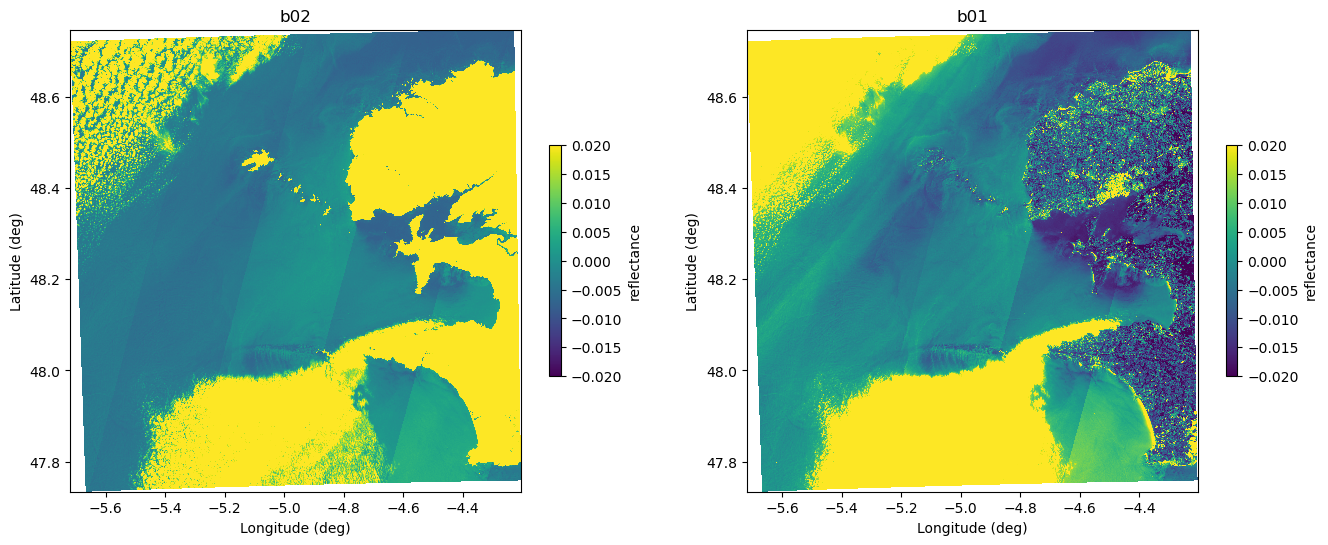

In [8]:
from foscat.Plot import plot_image_latlon

x_vals = ds.x.compute()
y_vals = ds.y.compute() 

# compute coordinate of the patch
xx, yy = np.meshgrid(x_vals, y_vals)
lon, lat = transformer.transform(xx, yy)

fig=plt.figure(figsize=(16,6))

ax=plt.subplot(1,2,1)
plot_image_latlon(fig,ax,ds["b09"].values-np.median(ds["b09"].values), lat, lon, mode="structured", shading="flat",vmin=-0.02,vmax=0.02,aspect="auto")
ax.set_title("b02")
ax=plt.subplot(1,2,2)
plot_image_latlon(fig,ax,ds["b01"].values-np.median(ds["b01"].values), lat, lon, mode="structured", shading="flat",vmin=-0.02,vmax=0.02,aspect="auto")
ax.set_title("b01")


### Key cell — Patch-wise UTM → HEALPix projection with **xbatcher** and inverse interpolation per band

This cell orchestrates a **patch-by-patch** conversion of Sentinel-2 image tiles (in UTM) to a **HEALPix** representation using **xbatcher** for tiling, and a **constrained inverse interpolation** to estimate the value of each HEALPix pixel so that the **HEALPix bilinear interpolation back to the UTM grid** reproduces the original image as closely as possible.

**What it does, step by step**

1. **Batching (xbatcher)**  
   - The UTM image is partitioned into fixed-size patches (`pix_step × pix_step`, default `128×128`).  
   - This keeps memory usage low and enables scalable, parallel processing.

2. **Per-patch coordinate transform**  
   - For each patch, the code builds the (x, y) mesh in UTM, converts it to (lon, lat), and then to spherical angles `(theta, phi)`.

3. **Forward model: HEALPix → UTM via interpolation weights**  
   - Using `healpy.get_interp_weights(nside, theta, phi, nest=True)`, we retrieve, for each UTM pixel center, the **indices** of the HEALPix pixels and the **weights** that HEALPix would use to interpolate **from** HEALPix pixel values **to** that UTM location.  
   - Think of this as building a (very sparse) matrix **A** such that `u_utm ≈ A · v_hp`, where `v_hp` are unknown HEALPix pixel values on this patch footprint, and `u_utm` are the observed UTM pixel values.

4. **Inverse problem (per band)**  
   - For each band (B02 and B04), we **solve the normal equations** `AᵀA v_hp = Aᵀ u_utm` using a **conjugate-gradient** solver (`conjugate_gradient_normal_equation`).  
   - The solution **v_hp** is the set of HEALPix pixel values that, when interpolated with the same weights **A**, best reproduces the original UTM patch (in a least-squares sense).

5. **Quality and stability tweaks**  
   - The code filters cells that do not have enough contributing samples and renormalizes weights to avoid NaNs.  
   - This stabilizes the local inversion, especially along patch borders or near sparse sampling.

6. **Outputs per patch**  
   - `(vals_1, vals_2, cell_ids)`: the reconstructed HEALPix values for B02 and B04 and the corresponding HEALPix cell IDs (NESTED order) touched by the patch.

**Why this is effective**

- The process is **explicitly local and batched** (thanks to xbatcher), so it scales to very large scenes while keeping memory bounded.  
- By **matching the forward interpolation** used by HEALPix, the recovered HEALPix map is directly optimized for later **interpolated queries** (e.g., back to regular grids or to spectral/wavelet operators on the sphere).  
- Solving the **inverse interpolation** rather than simple bin-averaging gives a HEALPix field that is **closest (in least-squares sense)** to the original UTM radiometry when sampled through the same HEALPix interpolant.

<img src="Bi-linear-plot.png" alt="Bi-linear interpolation" style="width:50%;">

**Figure – Forward model and inverse problem between HEALPix and UTM grids.**  
For each UTM pixel center, `healpy.get_interp_weights` provides the indices of the four neighboring HEALPix cells and the corresponding interpolation weights ( $W_0, W_1, W_2, W_3$).  
This defines a sparse linear operator **A** such that `u_utm ≈ A · v_hp`, where `u_utm` are the observed UTM pixel values and `v_hp` are the unknown HEALPix values.  
The inverse problem is then solved per band (B02, B04) by minimizing the least-squares misfit through the conjugate-gradient solution of `AᵀA v_hp = Aᵀ u_utm`, ensuring that the HEALPix map reproduces the UTM data as faithfully as possible under the HEALPix interpolation scheme.



In [9]:
import dask
import xarray as xr
from xbatcher import BatchGenerator
import healpy as hp
import foscat.SphericalStencil as st
from tqdm.auto import tqdm
import numpy as np
from foscat.Plot import conjugate_gradient_normal_equation

# Define a spherical stencil for wavelet processing at a given HEALPix resolution
f = st.SphericalStencil(2**19, 3)


def count_patches(xobj, input_dims, input_overlap):
    """
    Count the total number of windows (patches) generated by xbatcher.
    
    Parameters
    ----------
    xobj : xr.DataArray or xr.Dataset
        The input xarray object with spatial dimensions.
    input_dims : dict
        Window sizes for each dimension.
    input_overlap : dict
        Overlap sizes for each dimension.

    Returns
    -------
    int
        Total number of patches that will be generated.
    """
    stride = {k: input_dims[k] - input_overlap.get(k, 0) for k in input_dims}
    n = 1
    for dim, win in input_dims.items():
        step = stride[dim]
        size = xobj.sizes[dim]
        # number of positions along this dimension = sliding window formula
        n_dim = max(0, (size - win) // step + 1)
        n *= n_dim
    return n


band=['b01','b09','b10']

def to_healpix_dask(
    level: int,
    ds: xr.Dataset,
    *,
    pix_step: int = 128,
    transformer=None,
    prefer_kdtree: bool = True,
    frac_overlap: float = 0.05
):
    """
    Build a list of patch results, each computing (vals_b02, vals_b04, cell_ids).
    
    Each patch is extracted in UTM coordinates, then projected into HEALPix.
    The HEALPix values are estimated so that bilinear interpolation of the
    HEALPix map reproduces the original UTM values as closely as possible.
    """
    assert transformer is not None, "You must pass a CRS transformer with .transform(X, Y)."

    band = ds
    assert {"x", "y"} <= set(band.dims)

    pix_step = int(pix_step)

    overlap_y = int(round(frac_overlap * pix_step))
    overlap_x = int(round(frac_overlap * pix_step))
    
    # Effective stride = pix_step - overlap
    stride_y = pix_step - overlap_y
    stride_x = pix_step - overlap_x
    
    input_dims = {"y": pix_step, "x": pix_step}
    input_overlap = {"y": overlap_y, "x": overlap_x}

    # Safety check: all values must be integers
    for k, v in input_dims.items():
        if not isinstance(v, (int, np.integer)):
            raise TypeError(f"input_dims[{k}] must be int, got {type(v)} -> {v}")
    for k, v in input_overlap.items():
        if not isinstance(v, (int, np.integer)):
            raise TypeError(f"input_overlap[{k}] must be int, got {type(v)} -> {v}")

    print(input_dims)
    print(input_overlap)
    # Generator of patches along dimensions (y, x)
    gen = BatchGenerator(
        band,  # input dataset containing bands b02, b04
        input_dims=input_dims,
        input_overlap=input_overlap,
    )

    total = count_patches(band, input_dims, input_overlap)

    def _process_patch(patch_ds, x_vals, y_vals):
        """
        Project one patch from UTM to HEALPix and solve for band values.
        """
        band=['b01','b09','b10']
        # Ensure x and y coordinates are NumPy arrays
        x_vals = x_vals.compute() if hasattr(x_vals, "compute") else np.asarray(x_vals)
        y_vals = y_vals.compute() if hasattr(y_vals, "compute") else np.asarray(y_vals)

        # Build meshgrid of UTM coordinates
        xx, yy = np.meshgrid(x_vals, y_vals)

        # Convert UTM -> lon/lat
        lon, lat = transformer.transform(xx, yy)

        ivals=np.zeros([3,patch_ds[band[0]].values.flatten().shape[0]])
        for k in range(3):
            ivals[k]=patch_ds[band[k]].values.flatten()

        idx=np.where(np.isfinite(ivals[0])&np.isfinite(ivals[1])&np.isfinite(ivals[2]))[0]
        ivals=ivals[:,idx]
        lon=lon.flatten()[idx]
        lat=lat.flatten()[idx]
        
        # Convert lon/lat to HEALPix spherical angles
        theta = np.deg2rad(90.0 - lat)
        phi   = np.deg2rad(lon)

        nside = 2**level

        # Compute interpolation indices and weights (HEALPix -> UTM pixels)
        I, W = hp.get_interp_weights(nside, theta, phi, nest=True)

        # Identify unique HEALPix cells and build inverse indices
        cell_ids, indices = np.unique(I, return_inverse=True)

        # Reject cells with too few contributions
        valid_cell = np.bincount(indices.flatten(), W.flatten())
        W *= valid_cell[indices] > 1.0
        W /= np.sum(W, 0)[None, :]
        W[~np.isfinite(W)] = 0.0

        # Recompute valid_cell after cleaning
        valid_cell = np.bincount(indices.flatten(), W.flatten())
        i = 0
        # Find a valid replacement cell index for "empty" slots
        while valid_cell[i] != 0 and i < cell_ids.shape[0] - 1:
            i += 1
        I[valid_cell[indices] == 0] = cell_ids[i]

        # Compute HEALPix cell ids for all (theta, phi)
        cell_ids = hp.ang2pix(nside, theta, phi, nest=True)

        # Re-identify unique cell ids and inverse indices
        cell_ids, indices = np.unique(I, return_inverse=True)

        # Extract band values from the patch
        vals=np.zeros([3,cell_ids.shape[0]])
        for k in range(3):
            # Solve the inverse interpolation problem for each band
            vals[k] = conjugate_gradient_normal_equation(
                ivals[k],
                np.zeros([cell_ids.shape[0]]),
                W,
                indices,
                max_iter=100,
                verbose=False,
            )

        return vals, cell_ids

    data = []
    for patch in tqdm(gen, total=total, desc="Queuing patches"):
        # Extract coordinate slices for this patch
        x_slice = patch.coords["x"].data
        y_slice = patch.coords["y"].data
        # Process one patch (currently eager; could be wrapped with dask.delayed)
        l_data = _process_patch(patch, x_slice, y_slice)
        data.append(l_data)

    return data

### Build all tiles (UTM → HEALPix, patch by patch)

This cell launches the patch-wise conversion by calling `to_healpix_dask(level=19, ds=ds, pix_step=256, transformer=transformer)`:

it iterates over the Sentinel-2 image in **128×128** UTM patches (via **xbatcher**), converts each patch’s coordinates to **HEALPix**, solves the inverse interpolation for **B02** and **B04**, and returns a Python list where each entry contains the reconstructed HEALPix values and the corresponding cell IDs for that patch—keeping memory low and preparing data for the subsequent spectral analysis.

In [10]:
# Build all tiles
level=16
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)

{'y': 1830, 'x': 1830}
{'y': 92, 'x': 92}


Queuing patches:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
data[0]

(array([[0.        , 0.13547706, 0.1350508 , ..., 0.22415779, 0.18283239,
         0.18450663],
        [0.        , 0.0099284 , 0.01006868, ..., 0.04409882, 0.02391562,
         0.02422633],
        [0.        , 0.00075631, 0.00092025, ..., 0.00117013, 0.00083621,
         0.00084627]], shape=(3, 1215471)),
 array([14454357501, 14454357503, 14454357757, ..., 14479065091,
        14479065092, 14479065096], shape=(1215471,)))

### Visualize the first HEALPix patches with local gnomonic projection

This cell uses **foscat’s `lgnomproject`** function to display the first four processed patches.  
For each patch, the HEALPix values are projected back onto a local tangent plane (gnomonic projection):

- The **top row** shows B02 results (`data[k][0]`) after subtracting the median to highlight local variations.  
- The **bottom row** shows B04 results (`data[k][1]`) in the same way.  

Both are displayed with the same color scale (`vmin=-0.02`, `vmax=0.02`) for consistent comparison.  
This visualization step is mainly for **demo and sanity-check purposes**: it helps confirm that the HEALPix inversion has preserved the image structure of each patch.

In [13]:
hidx=data[0][1].copy()
all_data=data[0][0].copy()
print(all_data.shape,hidx.shape)
for k in range(1,len(data)):
    tmp_idx=np.concatenate([data[k][1],hidx],0)
    hidx,indices=np.unique(tmp_idx,return_inverse=True)
    www=1/np.bincount(indices)
    
    tmp=np.concatenate([data[k][0],all_data],1)
    print(tmp.shape,indices.shape)
    all_data=np.bincount(np.tile(indices,3)+(indices.max()+1)*np.repeat(np.arange(3),indices.shape[0]),
                         tmp.flatten())
    all_data=all_data.reshape(3,all_data.shape[0]//3)*www[None,:]

(3, 1215471) (1215471,)


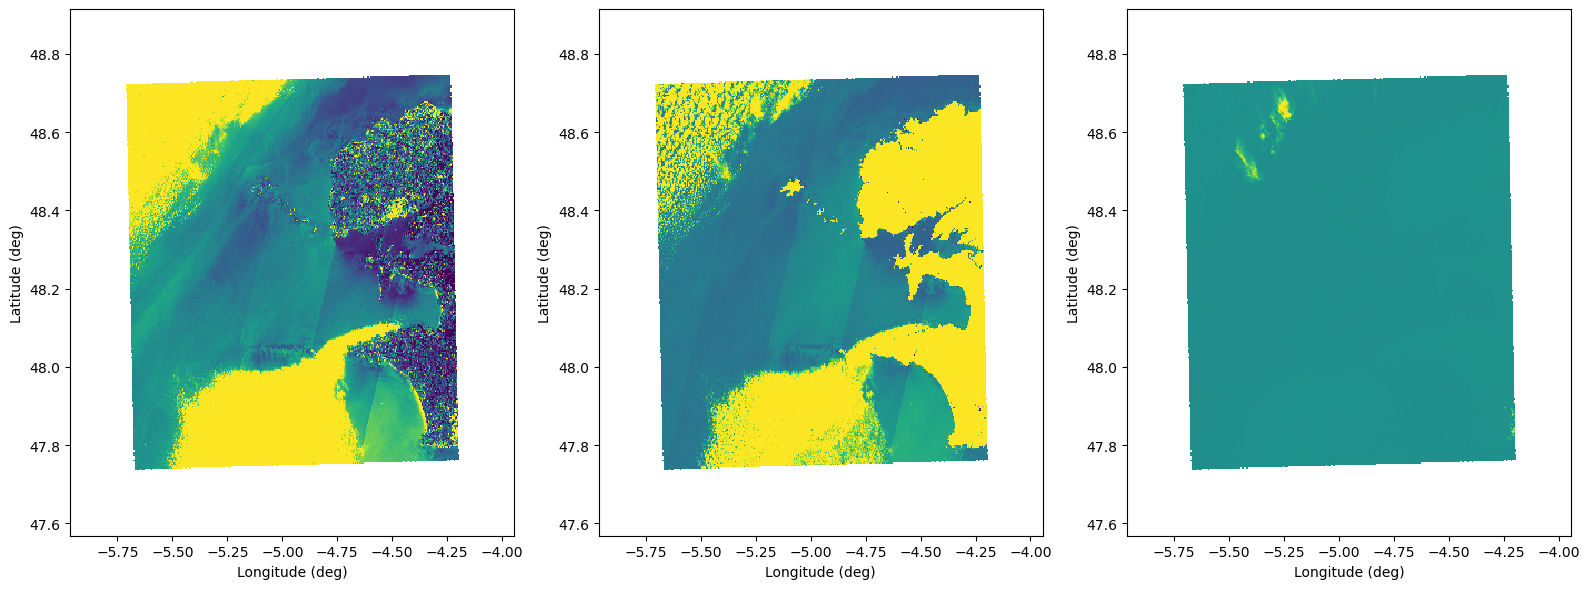

In [14]:
plt.figure(figsize=(16,6))

for k in range(3):
    lgnomproject(hidx,all_data[k]-np.median(all_data[k]),2**level,hold=False,sub=(1,3,1+k),vmax=0.02,vmin=-0.02)

<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

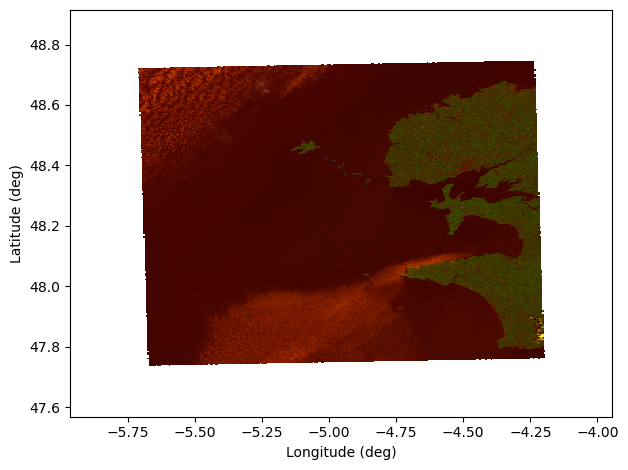

In [15]:
 lgnomproject(hidx,2*all_data.T,2**level,hold=False,sub=(1,1,1))

In [16]:
# Access cloud-optimized Sentinel-2 data via the EOPF STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

def get_ds(LON,LAT,date = "2025-06-17/2025-06-17"):
    # Search criteria optimized for wave analysis
    collections = ["sentinel-2-l1c"]
    items = list(
        catalog.search(
            datetime=date,
            collections=collections,
            intersects=dict(type="Point", coordinates=[LON, LAT]),
            query={
                "eo:cloud_cover": {
                    "lt": 100
                },  # Cloud cover < 20% ensures clear ocean surface
                "view:sun_elevation": {
                    "gt": 0.0
                },  # Filter for high sun elevation > 25° (→ sun zenith angle < 65°),
                # which places the sun near the zenith.
            },
        ).items()
    )
    
    for item in items:
        print(f"✅ {item.id}")
    else:
        print("No items found for the given criteria.")

    item = items[0]
    # Open the dataset lazily from object storage
    dt = xr.open_datatree(
        item.assets["product"].href,
        **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
    )
    
    return dt["measurements"]["reflectance"]["r60m"]

# Define oceanographic study area and time window
LON, LAT = -3.0, 48  # Bay of Biscay - known for consistent wave patterns

def merge_data(data,hidx,all_data):
    print(len(data))
    for k in range(len(data)):
        tmp_idx=np.concatenate([data[k][1],hidx],0)
        hidx,indices=np.unique(tmp_idx,return_inverse=True)
        www=1/np.bincount(indices)
        
        tmp=np.concatenate([data[k][0],all_data],1)
        all_data=np.bincount(np.tile(indices,3)+(indices.max()+1)*np.repeat(np.arange(3),indices.shape[0]),
                             tmp.flatten())
        all_data=all_data.reshape(3,all_data.shape[0]//3)*www[None,:]
    return hidx,all_data

ds=get_ds(-4.5,48)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx=data[0][1].copy()
all_data=data[0][0].copy()
hidx,all_data=merge_data(data,hidx,all_data)
ds=get_ds(-4.0,48)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)
ds=get_ds(-3.0,48)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)

ds=get_ds(-4.5,47.5)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)
ds=get_ds(-4.0,47.5)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)
ds=get_ds(-4.0,47.5)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)


ds=get_ds(-4.5,49)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)
ds=get_ds(-4.0,49)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)
ds=get_ds(-3.0,49)
data = to_healpix_dask(level=level, ds=ds, pix_step=1830, transformer=transformer)
hidx,all_data=merge_data(data,hidx,all_data)

✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UUU_20250617T131418
No items found for the given criteria.
{'y': 1830, 'x': 1830}
{'y': 92, 'x': 92}


Queuing patches:   0%|          | 0/1 [00:00<?, ?it/s]

1
✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UVU_20250617T131418
No items found for the given criteria.
{'y': 1830, 'x': 1830}
{'y': 92, 'x': 92}


Queuing patches:   0%|          | 0/1 [00:00<?, ?it/s]

1
✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UWU_20250617T131418
✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UVU_20250617T131418
No items found for the given criteria.
{'y': 1830, 'x': 1830}
{'y': 92, 'x': 92}


...

1
✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UVV_20250617T131418
No items found for the given criteria.
{'y': 1830, 'x': 1830}
{'y': 92, 'x': 92}


Queuing patches:   0%|          | 0/1 [00:00<?, ?it/s]

1
✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UWV_20250617T131418
✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UVV_20250617T131418
No items found for the given criteria.
{'y': 1830, 'x': 1830}
{'y': 92, 'x': 92}


Queuing patches:   0%|          | 0/1 [00:00<?, ?it/s]

1


<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

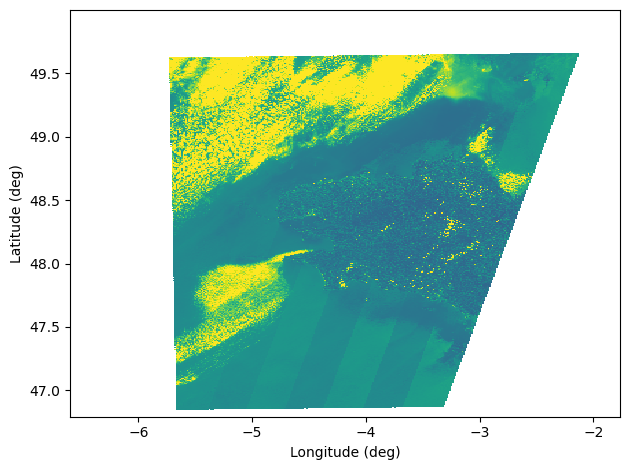

In [17]:
lgnomproject(hidx,all_data[0]-np.median(all_data[0]),2**level,hold=False,sub=(1,1,1),vmax=0.1,vmin=-0.1)

In [18]:
var_cell_ids = xr.DataArray(
        hidx,
        dims="cells",
        attrs={"grid_name": "healpix", "nside": 2**level, "nest": True},
    )

out_map = []
for k in range(3):
    out_map.append(
            xr.DataArray(
                all_data[k],
                dims=("cells"),
                coords={"cell_ids": var_cell_ids},
                name=band[k],
            )
        )
ds_total = xr.merge(out_map)

In [19]:
ds_total

<xarray.Dataset> Size: 221MB
Dimensions:   (cells: 6904568)
Coordinates:
    cell_ids  (cells) int64 55MB 14446985181 14446985182 ... 14481244714
Dimensions without coordinates: cells
Data variables:
    b01       (cells) float64 55MB 0.1363 0.1371 0.1363 ... 0.2312 0.2421 0.2371
    b09       (cells) float64 55MB 0.01862 0.01886 0.0182 ... 0.04694 0.04315
    b10       (cells) float64 55MB 0.001196 0.001581 ... 0.00528 0.004923

In [28]:
storage_options = {"endpoint_url": "https://pangeo-eosc-minioapi.vm.fedcloud.eu/", "anon": True} #| credentials

ds_total.to_zarr("s3://group-01-public/sentinel_bids25_demo.zarr", storage_options=storage_options, mode="w")